In [33]:
import pandas as pd
import numpy as np
import joblib

import matplotlib.pyplot as plt
import seaborn as sns

from pathlib import Path

In [34]:
train_df = pd.read_csv("../data/train_FD001.txt", sep=r"\s+", header=None)

In [35]:
column_names = [
    "engine_id",
    "cycle",
    "op_setting_1",
    "op_setting_2",
    "op_setting_3"
]

for i in range(1, 22):
    column_names.append(f"sensor_{i}")

train_df.columns = column_names

train_df.head()

,engine_id,cycle,op_setting_1,op_setting_2,op_setting_3,sensor_1,sensor_2,sensor_3,sensor_4,sensor_5,...,sensor_12,sensor_13,sensor_14,sensor_15,sensor_16,sensor_17,sensor_18,sensor_19,sensor_20,sensor_21
0,1,1,-0.0007,-0.0004,100.0,518.67,641.82,1589.70,1400.60,14.62,...,521.66,2388.02,8138.62,8.4195,0.03,392,2388,100.0,39.06,23.4190
1,1,2,0.0019,-0.0003,100.0,518.67,642.15,1591.82,1403.14,14.62,...,522.28,2388.07,8131.49,8.4318,0.03,392,2388,100.0,39.00,23.4236
2,1,3,-0.0043,0.0003,100.0,518.67,642.35,1587.99,1404.20,14.62,...,522.42,2388.03,8133.23,8.4178,0.03,390,2388,100.0,38.95,23.3442
3,1,4,0.0007,0.0000,100.0,518.67,642.35,1582.79,1401.87,14.62,...,522.86,2388.08,8133.83,8.3682,0.03,392,2388,100.0,38.88,23.3739
4,1,5,-0.0019,-0.0002,100.0,518.67,642.37,1582.85,1406.22,14.62,...,522.19,2388.04,8133.80,8.4294,0.03,393,2388,100.0,38.90,23.4044


In [36]:
#Create RUL target
max_cycle = (
    train_df
    .groupby("engine_id")["cycle"]
    .max()
    .reset_index()
)

max_cycle.columns = ["engine_id", "max_cycle"]

train_df = train_df.merge(
    max_cycle,
    on="engine_id"
)

train_df["RUL"] = (
    train_df["max_cycle"]
    - train_df["cycle"]
)

train_df.drop(
    columns=["max_cycle"],
    inplace=True
)

train_df.head()

,engine_id,cycle,op_setting_1,op_setting_2,op_setting_3,sensor_1,sensor_2,sensor_3,sensor_4,sensor_5,...,sensor_13,sensor_14,sensor_15,sensor_16,sensor_17,sensor_18,sensor_19,sensor_20,sensor_21,RUL
0,1,1,-0.0007,-0.0004,100.0,518.67,641.82,1589.70,1400.60,14.62,...,2388.02,8138.62,8.4195,0.03,392,2388,100.0,39.06,23.4190,191
1,1,2,0.0019,-0.0003,100.0,518.67,642.15,1591.82,1403.14,14.62,...,2388.07,8131.49,8.4318,0.03,392,2388,100.0,39.00,23.4236,190
2,1,3,-0.0043,0.0003,100.0,518.67,642.35,1587.99,1404.20,14.62,...,2388.03,8133.23,8.4178,0.03,390,2388,100.0,38.95,23.3442,189
3,1,4,0.0007,0.0000,100.0,518.67,642.35,1582.79,1401.87,14.62,...,2388.08,8133.83,8.3682,0.03,392,2388,100.0,38.88,23.3739,188
4,1,5,-0.0019,-0.0002,100.0,518.67,642.37,1582.85,1406.22,14.62,...,2388.04,8133.80,8.4294,0.03,393,2388,100.0,38.90,23.4044,187


In [37]:
sensor_cols = [
    "sensor_2",
    "sensor_4",
    "sensor_11",
    "sensor_15",
    "sensor_17"
]

In [38]:
#Rolling averages
for sensor in sensor_cols:

    train_df[f"{sensor}_avg5"] = (
        train_df
        .groupby("engine_id")[sensor]
        .transform(
            lambda x: x.rolling(
                5,
                min_periods=1
            ).mean()
        )
    )

    train_df[f"{sensor}_avg10"] = (
        train_df
        .groupby("engine_id")[sensor]
        .transform(
            lambda x: x.rolling(
                10,
                min_periods=1
            ).mean()
        )
    )

    train_df[f"{sensor}_avg20"] = (
        train_df
        .groupby("engine_id")[sensor]
        .transform(
            lambda x: x.rolling(
                20,
                min_periods=1
            ).mean()
        )
    )

    train_df[f"{sensor}_avg30"] = (
        train_df
        .groupby("engine_id")[sensor]
        .transform(
            lambda x: x.rolling(
                30,
                min_periods=1
            ).mean()
        )
    )

In [39]:
#Difference features
for sensor in sensor_cols:

    train_df[f"{sensor}_diff"] = (
        train_df
        .groupby("engine_id")[sensor]
        .diff()
        .fillna(0)
    )

In [40]:
#load models
health_model = joblib.load(
    "../models/rf_health_classifier.pkl"
)

rul_model = joblib.load(
    "../models/rul_model.pkl"
)

health_features = joblib.load(
    "../models/model_features.pkl"
)

rul_features = joblib.load(
    "../models/rul_features.pkl"
)

class_labels = joblib.load(
    "../models/class_labels.pkl"
)

In [41]:
#Create dashboard datasheet
dashboard_df = train_df.copy()

dashboard_df.shape

(20631, 52)

In [48]:
# Health predictions

dashboard_df["Health_Status"] = (
    health_model.predict(
        dashboard_df[health_features]
    )
)

dashboard_df["Health_Status"].value_counts()

Health_Status
Healthy     10630
Warning      6939
Critical     3062
Name: count, dtype: int64

In [49]:
health_score_map = {
    "Healthy": 90,
    "Warning": 60,
    "Critical": 20
}

dashboard_df["Health_Score"] = (
    dashboard_df["Health_Status"]
    .map(health_score_map)
)

dashboard_df[
    ["Health_Status", "Health_Score"]
].head()

,Health_Status,Health_Score
0,Healthy,90
1,Healthy,90
2,Healthy,90
3,Healthy,90
4,Healthy,90


In [50]:
dashboard_df["Predicted_RUL"] = (
    rul_model.predict(
        dashboard_df[rul_features]
    )
)

dashboard_df["Predicted_RUL"].describe()

count    20631.000000
mean       108.101565
std         65.287198
min          0.236229
25%         54.502576
50%        104.809895
75%        156.976019
max        345.475556
Name: Predicted_RUL, dtype: float64

In [51]:
#Create fleet datasheet
fleet_df = (
    dashboard_df
    .sort_values(["engine_id", "cycle"])
    .groupby("engine_id")
    .tail(1)
    .reset_index(drop=True)
)

fleet_df.shape

(100, 55)

In [52]:
fleet_df[
    ["engine_id","cycle","Predicted_RUL"]
].sort_values("Predicted_RUL")

,engine_id,cycle,Predicted_RUL
90,91,135,0.236229
12,13,163,0.260286
23,24,147,0.277316
79,80,185,0.299770
75,76,210,0.314172
...,...,...,...
26,27,156,2.938808
7,8,150,3.820000
30,31,234,3.846824
85,86,278,5.983333


In [53]:
fleet_df[
    ["engine_id","cycle","Predicted_RUL"]
].sort_values("Predicted_RUL", ascending=False).head(20)

,engine_id,cycle,Predicted_RUL
41,42,196,6.485000
85,86,278,5.983333
30,31,234,3.846824
7,8,150,3.820000
26,27,156,2.938808
47,48,231,2.576667
97,98,156,2.513631
44,45,158,2.279314
53,54,257,2.119048
11,12,170,1.973221


In [54]:
fleet_df["Predicted_RUL"].describe()

count    100.000000
mean       1.007534
std        1.027126
min        0.236229
25%        0.446441
50%        0.631289
75%        1.166653
max        6.485000
Name: Predicted_RUL, dtype: float64

In [55]:
dashboard_df.shape

(20631, 55)

In [56]:
fleet_df.shape

(100, 55)

In [57]:
dashboard_df[
    ["engine_id","cycle","Predicted_RUL"]
].sort_values(["engine_id","cycle"]).tail(20)

,engine_id,cycle,Predicted_RUL
20611,100,181,19.853551
20612,100,182,19.080000
20613,100,183,17.569778
20614,100,184,17.276667
20615,100,185,15.130000
20616,100,186,14.930417
20617,100,187,12.826957
20618,100,188,12.985833
20619,100,189,14.576111
20620,100,190,11.213084


In [58]:
fleet_df[
    ["engine_id","cycle","Predicted_RUL"]
].head(20)

,engine_id,cycle,Predicted_RUL
0,1,192,1.020667
1,2,287,0.363525
2,3,179,1.550325
3,4,189,0.344083
4,5,269,0.424007
5,6,188,1.161333
6,7,259,0.890000
7,8,150,3.820000
8,9,201,1.966667
9,10,222,1.739722


In [59]:
dashboard_df[
    dashboard_df["engine_id"] == 1
][["cycle","Predicted_RUL"]].tail(20)

,cycle,Predicted_RUL
172,173,21.758750
173,174,20.526053
174,175,17.878553
175,176,18.719500
176,177,17.913864
177,178,14.313910
178,179,13.278275
179,180,12.886988
180,181,13.391206
181,182,10.705740


In [60]:
dashboard_df[
    dashboard_df["engine_id"] == 1
][["cycle","Predicted_RUL"]].tail(20)

,cycle,Predicted_RUL
172,173,21.758750
173,174,20.526053
174,175,17.878553
175,176,18.719500
176,177,17.913864
177,178,14.313910
178,179,13.278275
179,180,12.886988
180,181,13.391206
181,182,10.705740


In [61]:
# Create latest engine snapshot

fleet_df = (
    dashboard_df
    .sort_values(["engine_id", "cycle"])
    .groupby("engine_id")
    .tail(1)
    .reset_index(drop=True)
)

fleet_df.shape

(100, 55)

In [62]:
fleet_df[
    ["engine_id", "cycle", "Health_Status", "Predicted_RUL"]
].head()

,engine_id,cycle,Health_Status,Predicted_RUL
0,1,192,Critical,1.020667
1,2,287,Critical,0.363525
2,3,179,Critical,1.550325
3,4,189,Critical,0.344083
4,5,269,Critical,0.424007


In [63]:
#Create fleet snapshot (100 engines)
fleet_df = (
    dashboard_df
    .sort_values(["engine_id", "cycle"])
    .groupby("engine_id")
    .tail(1)
    .reset_index(drop=True)
)

fleet_df.shape

(100, 55)

In [64]:
#Create health score
fleet_df["Health_Score"] = (
    fleet_df["Predicted_RUL"]
    / fleet_df["Predicted_RUL"].max()
) * 100

fleet_df["Health_Score"] = (
    fleet_df["Health_Score"]
    .round(0)
    .astype(int)
)

fleet_df[
    ["engine_id","Predicted_RUL","Health_Score"]
].head()

,engine_id,Predicted_RUL,Health_Score
0,1,1.020667,16
1,2,0.363525,6
2,3,1.550325,24
3,4,0.344083,5
4,5,0.424007,7


In [65]:
#Dashboard KPI cards
total_engines = fleet_df.shape[0]

healthy_engines = (
    fleet_df["Health_Status"] == "Healthy"
).sum()

warning_engines = (
    fleet_df["Health_Status"] == "Warning"
).sum()

critical_engines = (
    fleet_df["Health_Status"] == "Critical"
).sum()

avg_rul = round(
    fleet_df["Predicted_RUL"].mean(),
    2
)

print("Total Engines :", total_engines)
print("Healthy :", healthy_engines)
print("Warning :", warning_engines)
print("Critical :", critical_engines)
print("Average RUL :", avg_rul)

Total Engines : 100
Healthy : 0
Critical : 100
Average RUL : 1.01


In [66]:
import pandas as pd

fleet_df = (
    dashboard_df
    .groupby("engine_id", group_keys=False)
    .apply(lambda x: x.sample(1, random_state=42))
    .reset_index(drop=True)
)

fleet_df.shape

C:\Users\saees\AppData\Local\Temp\ipykernel_3372\2178462108.py:6: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(lambda x: x.sample(1, random_state=42))


(100, 55)

In [67]:
fleet_df["Predicted_RUL"].describe()

count    100.000000
mean     107.723146
std       76.903474
min        2.117668
25%       36.381432
50%       96.571434
75%      173.571809
max      277.196667
Name: Predicted_RUL, dtype: float64

In [68]:
fleet_df["Health_Status"] = pd.cut(
    fleet_df["Predicted_RUL"],
    bins=[-1, 50, 150, float("inf")],
    labels=["Critical", "Warning", "Healthy"]
)

In [69]:
fleet_df["Health_Status"].value_counts()

Health_Status
Warning     34
Healthy     34
Critical    32
Name: count, dtype: int64

In [70]:
fleet_df["Predicted_RUL"].describe()

fleet_df["Health_Status"].value_counts()

Health_Status
Warning     34
Healthy     34
Critical    32
Name: count, dtype: int64

In [71]:
#Create health score
fleet_df["Health_Score"] = (
    fleet_df["Predicted_RUL"]
    / fleet_df["Predicted_RUL"].max()
) * 100

fleet_df["Health_Score"] = (
    fleet_df["Health_Score"]
    .round(0)
    .astype(int)
)

fleet_df[
    ["engine_id","Predicted_RUL","Health_Score"]
].head()

,engine_id,Predicted_RUL,Health_Score
0,1,153.775088,55
1,2,277.196667,100
2,3,123.264776,44
3,4,4.398394,2
4,5,231.836651,84


In [72]:
#KPI numbers
total_engines = len(fleet_df)

healthy_engines = (
    fleet_df["Health_Status"] == "Healthy"
).sum()

warning_engines = (
    fleet_df["Health_Status"] == "Warning"
).sum()

critical_engines = (
    fleet_df["Health_Status"] == "Critical"
).sum()

avg_rul = round(
    fleet_df["Predicted_RUL"].mean(),
    2
)

avg_health_score = round(
    fleet_df["Health_Score"].mean(),
    2
)

print("Total Engines:", total_engines)
print("Healthy:", healthy_engines)
print("Warning:", warning_engines)
print("Critical:", critical_engines)
print("Average RUL:", avg_rul)
print("Average Health Score:", avg_health_score)

Total Engines: 100
Healthy: 34
Critical: 32
Average RUL: 107.72
Average Health Score: 38.8


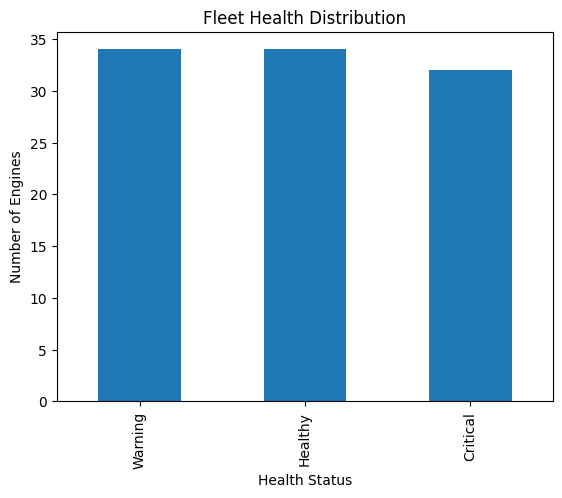

In [73]:
#Fleet health distribution chart
import matplotlib.pyplot as plt

fleet_df["Health_Status"].value_counts().plot(
    kind="bar"
)

plt.title("Fleet Health Distribution")
plt.xlabel("Health Status")
plt.ylabel("Number of Engines")

plt.show()

In [74]:
#top 10 critical engines
top_critical = (
    fleet_df[
        [
            "engine_id",
            "cycle",
            "Predicted_RUL",
            "Health_Status",
            "Health_Score"
        ]
    ]
    .sort_values("Predicted_RUL")
    .head(10)
)

top_critical

,engine_id,cycle,Predicted_RUL,Health_Status,Health_Score
39,40,184,2.117668,Critical,1
5,6,184,3.456667,Critical,1
3,4,185,4.398394,Critical,2
84,85,184,6.852762,Critical,2
88,89,206,9.476047,Critical,3
24,25,218,10.803333,Critical,4
74,75,217,11.636333,Critical,4
77,78,219,11.987755,Critical,4
47,48,219,12.446667,Critical,4
48,49,201,14.049722,Critical,5


In [75]:
#Top 10 healthiest egines
top_healthy = (
    fleet_df[
        [
            "engine_id",
            "cycle",
            "Predicted_RUL",
            "Health_Status",
            "Health_Score"
        ]
    ]
    .sort_values(
        "Predicted_RUL",
        ascending=False
    )
    .head(10)
)

top_healthy

,engine_id,cycle,Predicted_RUL,Health_Status,Health_Score
1,2,10,277.196667,Healthy,100
94,95,10,271.690000,Healthy,98
63,64,10,248.845879,Healthy,90
66,67,47,239.366961,Healthy,86
55,56,31,234.156667,Healthy,84
95,96,73,233.538770,Healthy,84
16,17,31,232.463193,Healthy,84
4,5,31,231.836651,Healthy,84
85,86,31,218.217219,Healthy,79
80,81,25,209.818755,Healthy,76


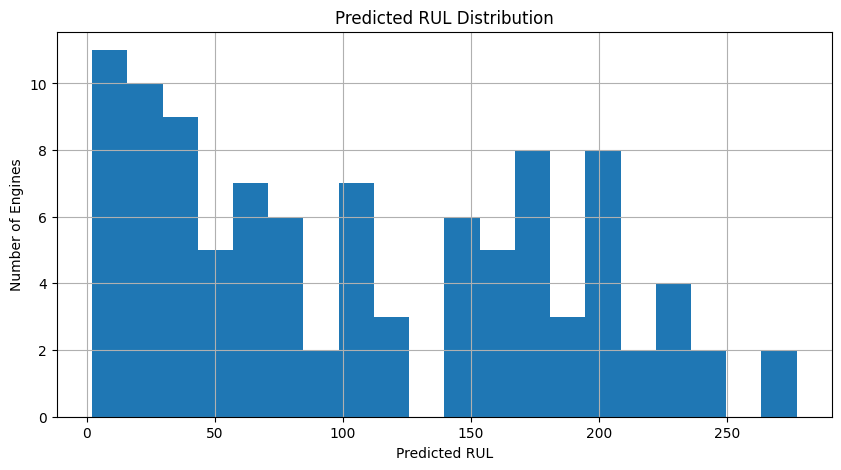

In [76]:
#RUL distribution histogram
plt.figure(figsize=(10,5))

fleet_df["Predicted_RUL"].hist(
    bins=20
)

plt.title("Predicted RUL Distribution")
plt.xlabel("Predicted RUL")
plt.ylabel("Number of Engines")

plt.show()

In [77]:
#Save final dashboard dataset
fleet_df.to_csv(
    "../data/fleet_dashboard.csv",
    index=False
)

print("Dashboard dataset saved.")

Dashboard dataset saved.


In [85]:
engine_id = 1

engine_data = dashboard_df[
    dashboard_df["engine_id"] == engine_id
]

engine_data.tail()

,engine_id,cycle,op_setting_1,op_setting_2,op_setting_3,sensor_1,sensor_2,sensor_3,sensor_4,sensor_5,...,sensor_17_avg20,sensor_17_avg30,sensor_2_diff,sensor_4_diff,sensor_11_diff,sensor_15_diff,sensor_17_diff,Health_Status,Health_Score,Predicted_RUL
187,1,188,-0.0067,0.0003,100.0,518.67,643.75,1602.38,1422.78,14.62,...,395.15,394.766667,0.43,-4.49,-0.23,-0.0011,0.0,Critical,20,4.200798
188,1,189,-0.0006,0.0002,100.0,518.67,644.18,1596.17,1428.01,14.62,...,395.20,394.800000,0.43,5.23,0.08,-0.0024,-1.0,Critical,20,3.248951
189,1,190,-0.0027,0.0001,100.0,518.67,643.64,1599.22,1425.95,14.62,...,395.35,394.866667,-0.54,-2.06,0.25,0.0040,3.0,Critical,20,2.016000
190,1,191,-0.0000,-0.0004,100.0,518.67,643.34,1602.36,1425.77,14.62,...,395.30,394.866667,-0.30,-0.18,-0.18,-0.0049,-4.0,Critical,20,1.558662
191,1,192,0.0009,-0.0000,100.0,518.67,643.54,1601.41,1427.20,14.62,...,395.45,394.933333,0.20,1.43,0.10,-0.0061,2.0,Critical,20,1.020667


In [86]:
engine_data.columns

Index(['engine_id', 'cycle', 'op_setting_1', 'op_setting_2', 'op_setting_3',
       'sensor_1', 'sensor_2', 'sensor_3', 'sensor_4', 'sensor_5', 'sensor_6',
       'sensor_7', 'sensor_8', 'sensor_9', 'sensor_10', 'sensor_11',
       'sensor_12', 'sensor_13', 'sensor_14', 'sensor_15', 'sensor_16',
       'sensor_17', 'sensor_18', 'sensor_19', 'sensor_20', 'sensor_21', 'RUL',
       'sensor_2_avg5', 'sensor_2_avg10', 'sensor_2_avg20', 'sensor_2_avg30',
       'sensor_4_avg5', 'sensor_4_avg10', 'sensor_4_avg20', 'sensor_4_avg30',
       'sensor_11_avg5', 'sensor_11_avg10', 'sensor_11_avg20',
       'sensor_11_avg30', 'sensor_15_avg5', 'sensor_15_avg10',
       'sensor_15_avg20', 'sensor_15_avg30', 'sensor_17_avg5',
       'sensor_17_avg10', 'sensor_17_avg20', 'sensor_17_avg30',
       'sensor_2_diff', 'sensor_4_diff', 'sensor_11_diff', 'sensor_15_diff',
       'sensor_17_diff', 'Health_Status', 'Health_Score', 'Predicted_RUL'],
      dtype='object')

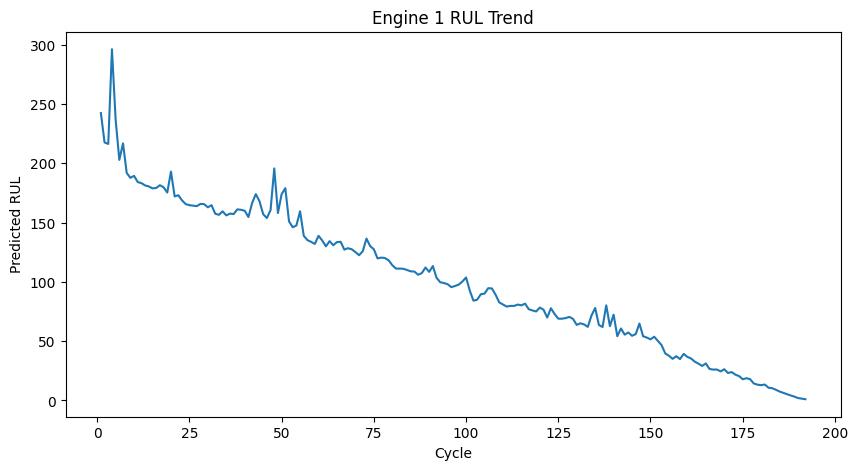

In [87]:
plt.figure(figsize=(10,5))

plt.plot(
    engine_data["cycle"],
    engine_data["Predicted_RUL"]
)

plt.title(f"Engine {engine_id} RUL Trend")
plt.xlabel("Cycle")
plt.ylabel("Predicted RUL")

plt.show()

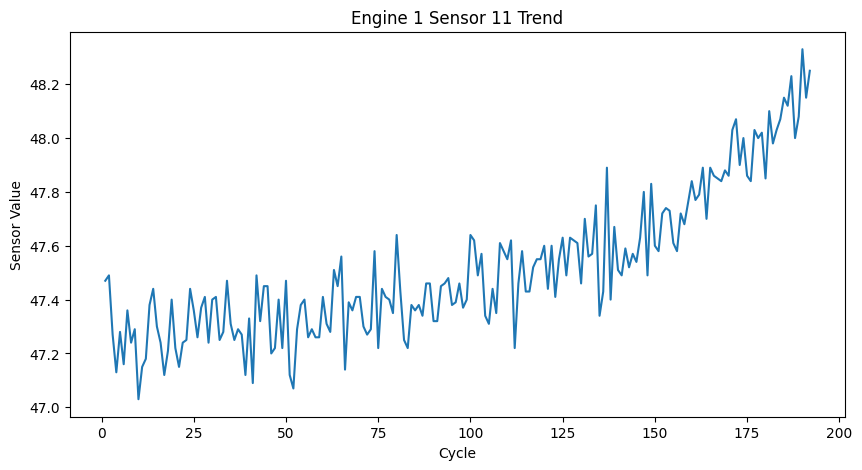

In [88]:
plt.figure(figsize=(10,5))

plt.plot(
    engine_data["cycle"],
    engine_data["sensor_11"]
)

plt.title(f"Engine {engine_id} Sensor 11 Trend")
plt.xlabel("Cycle")
plt.ylabel("Sensor Value")

plt.show()

In [89]:
def get_recommendation(status):

    if status == "Critical":
        return "Immediate Maintenance Required"

    elif status == "Warning":
        return "Schedule Maintenance Soon"

    return "Operating Normally"

In [90]:
fleet_df["Recommendation"] = (
    fleet_df["Health_Status"]
    .apply(get_recommendation)
)

In [94]:
fleet_df.to_csv(
    "../data/latest_engine_snapshot.csv",
    index=False
)

dashboard_df.to_csv(
    "../data/dashboard_predictions.csv",
    index=False
)

In [95]:
print("dashboard_df shape:", dashboard_df.shape)
print("fleet_df shape:", fleet_df.shape)

print("\nColumns:")
print(dashboard_df.columns.tolist())

dashboard_df shape: (20631, 56)
fleet_df shape: (100, 56)

Columns:
['engine_id', 'cycle', 'op_setting_1', 'op_setting_2', 'op_setting_3', 'sensor_1', 'sensor_2', 'sensor_3', 'sensor_4', 'sensor_5', 'sensor_6', 'sensor_7', 'sensor_8', 'sensor_9', 'sensor_10', 'sensor_11', 'sensor_12', 'sensor_13', 'sensor_14', 'sensor_15', 'sensor_16', 'sensor_17', 'sensor_18', 'sensor_19', 'sensor_20', 'sensor_21', 'RUL', 'sensor_2_avg5', 'sensor_2_avg10', 'sensor_2_avg20', 'sensor_2_avg30', 'sensor_4_avg5', 'sensor_4_avg10', 'sensor_4_avg20', 'sensor_4_avg30', 'sensor_11_avg5', 'sensor_11_avg10', 'sensor_11_avg20', 'sensor_11_avg30', 'sensor_15_avg5', 'sensor_15_avg10', 'sensor_15_avg20', 'sensor_15_avg30', 'sensor_17_avg5', 'sensor_17_avg10', 'sensor_17_avg20', 'sensor_17_avg30', 'sensor_2_diff', 'sensor_4_diff', 'sensor_11_diff', 'sensor_15_diff', 'sensor_17_diff', 'Health_Status', 'Health_Score', 'Predicted_RUL', 'Recommendation']


In [93]:
def get_recommendation(status):

    if status == "Critical":
        return "Immediate Maintenance Required"

    elif status == "Warning":
        return "Schedule Maintenance Soon"

    return "Operating Normally"

dashboard_df["Recommendation"] = (
    dashboard_df["Health_Status"]
    .apply(get_recommendation)
)

fleet_df["Recommendation"] = (
    fleet_df["Health_Status"]
    .apply(get_recommendation)
)

In [96]:
required_cols = [
    "engine_id",
    "cycle",
    "Health_Status",
    "Health_Score",
    "Predicted_RUL",
    "Recommendation"
]

missing = [
    col for col in required_cols
    if col not in dashboard_df.columns
]

if len(missing) == 0:
    print("✅ All required dashboard columns present")
else:
    print("❌ Missing columns:", missing)

✅ All required dashboard columns present
